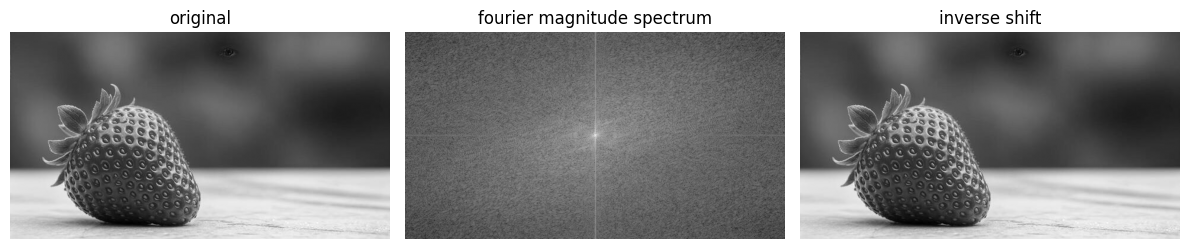

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 
image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
f_transform=np.fft.fft2(image)
f_shift=np.fft.fftshift(f_transform)
magnitude_shift=20*np.log(np.abs(f_shift)+1)
f_ishift=np.fft.ifftshift(f_shift)
img_back=np.fft.ifft2(f_ishift)
img_back=np.abs(img_back)

plt.figure(figsize=(12,6))
plt.subplot(131),plt.imshow(image,cmap='gray')
plt.title("original"),plt.axis('off')
plt.subplot(132),plt.imshow(magnitude_shift,cmap='gray')
plt.title("fourier magnitude spectrum"),plt.axis('off')
plt.subplot(133),plt.imshow(img_back,cmap='gray')
plt.title("inverse shift"),plt.axis('off')
plt.tight_layout()
plt.show()



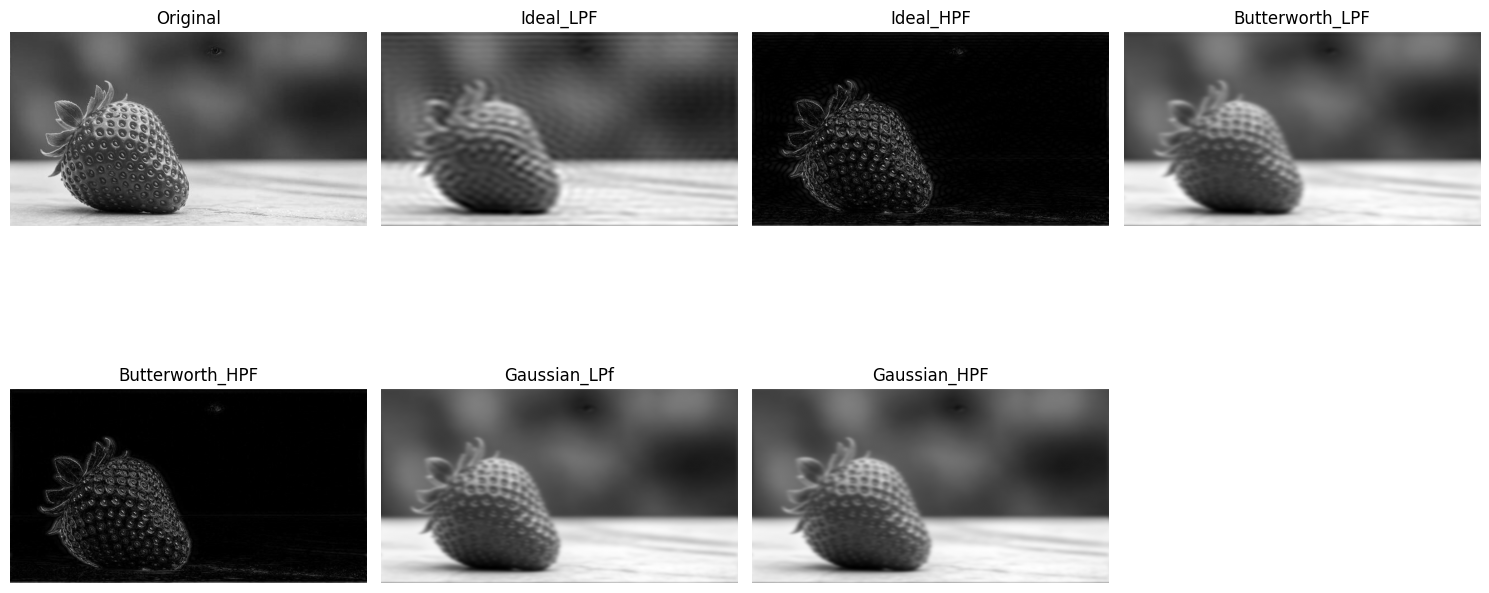

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
rows,cols=img.shape
cx,cy=rows // 2, cols //2

F=np.fft.fftshift(np.fft.fft2(img))

x=np.arange(cols) - cy
y=np.arange(rows) - cx

X,Y=np.meshgrid(x,y)
D=np.sqrt(X**2+Y**2)

D0,n=30,2

filters={
    'Ideal_LPF' : (D<=D0).astype(float),
    'Ideal_HPF' : (D>D0).astype(float),
    'Butterworth_LPF' : 1/(1+(D/D0)**(2*n)),
    'Butterworth_HPF' : 1/(1+(D0/(D+1e-6))**(2*n)),
    'Gaussian_LPf' : np.exp(-D**2/(2*D0**2)),
    'Gaussian_HPF' : np.exp(-D**2/(2*D0**2)),
}

plt.figure(figsize=(15,8))
plt.subplot(2,4,1)
plt.imshow(img,cmap='gray')
plt.title('Original'),plt.axis('off')

for i, (name, mask) in enumerate(filters.items(), start=2):
    filtered=np.abs(np.fft.ifft2(np.fft.ifftshift(F*mask)))
    plt.subplot(2,4,i)
    plt.imshow(filtered,cmap='gray')
    plt.title(name),plt.axis('off')
plt.tight_layout()
plt.show()


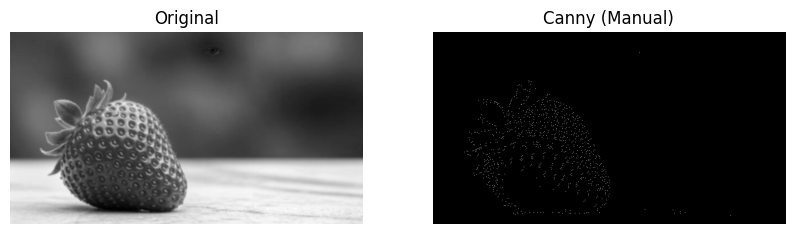

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

img = cv2.imread('image.jpg',0)
img=cv2.GaussianBlur(img,(5,5),1)
gx=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
gy=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
mag=np.sqrt(gx**2+gy**2)
mag=(mag/mag.max())*255

nms=np.where(mag==maximum_filter(mag,size=3),mag, 0)

low,high=30,80
edges=np.zeros_like(nms)
edges[nms>=high]=255
edges[(nms>=low)&(nms<high)]=75

strong_neighbors=maximum_filter(edges==255,size=3)
edges[(edges==75) & ~strong_neighbors]=0
edges[edges==75]=255

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis('off')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title("Canny (Manual)"), plt.axis('off')
plt.show()



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(img,seed,threshold):
    """
    Simple 4 connected region growing implementaion"""
    rows,cols = img.shape
    segmented=np.zeros((rows,cols),dtype=np.uint8)
    visited=np.zeros((rows,cols),dtype=bool)
    stack=[seed]
    seed_value=int(img[seed])
    visited[seed]=True
    while stack:
        y,x=stack.pop()
        segmented[y,x]=255
        for ny,nx in [(y-1,x),(y+1,x),(y,x-1),(y,x+1)]:
            if 0<=ny<rows and 0<=nx<cols and not visited[ny,nx]:
                if abs(int(img[ny,nx])-seed_value)<=threshold:
                    visited[ny,nx]=True
                    stack.append=True
    return segmented

image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
seed_point=(300,200)
threshold=30
result=region


plt.figure(figsize=(20,10))


